<img src="./Imagenes/logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos II

# Trabajo semanal 4
#### Alumno:    Lucas Gallero
#### Profesor:  Mariano Llamedo Soria  
#### Ayudante de TPs:    David Moharos
----

A partir de la siguiente plantilla:

<div align="center">
    <img src="./Imagenes/enunciado.png" alt="Plantilla de diseño" width="650"/>
</div>

1. Obtener la función transferencia $T(s)$ de Bessel para $N$: 2, 3 y 4 normalizados para $D(\omega = 0) = 1s$ utilizando el método de Storch:  
ver *Schaumann, R. - Van Valkenburg, Mac E., Design of Analog Filters, Capítulo 10: Delay Filters. Sección 10.2: Bessel-Thomson Response. Página 403.*



2. Elegir la $T(s)$ con el mínimo orden que cumpla con $\alpha_{máx}$ requerido.



3. Evaluar el retardo de grupo $D(\omega = 2.5)$ y expresar en forma porcentual [%] el error o desvío respecto a $D(\omega = 0)$.



4. Sintetizar el circuito **NORMALIZADO** con estructuras *Sallen-Key* con $K=1$ real, negativa y unitaria.



<div align="center">
    <img src="./Imagenes/enunciado2.png" alt="Circuito Sallen-Key" width="520"/>
</div>

---

## BONUS

* +10 💎 Simular **numéricamente en Python**.


* +10 💎 **DESNORMALIZAR** los componentes para obtener un $D(\omega = 0) = 200 \mu s$.



* +10 💎 Simular **circuitalmente en LTspice** con los valores **DESNORMALIZADOS** y medir el $D(\omega)$. (*)



* +10 🧑‍🏫 Presentación en **Jupyter Notebook**.



(*) Para medir el $D(\omega)$ en LTspice, haga click derecho en el eje vertical de la fase y seleccione `"Group Delay"` como lo indica la siguiente imagen:


<div align="center">
    <img src="./Imagenes/enunciado3.png" alt="Group Delay LTspice" width="650"/>
</div>

In [2]:
# PyTC2: La librería para TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot, plot_plantilla

from scipy.signal import TransferFunction
import scipy.signal as sig
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sympy as sp
from sympy.abc import s
from IPython.display import display, Math
from scipy import signal
from matplotlib.ticker import FuncFormatter
# las librerías que usarremos las cargamos solo una vez.

---

# 1) Obtenención de la función transferencia $T(s)$ de Bessel para $N$: 2, 3 y 4 normalizados para $D(\omega = 0) = 1s$ utilizando el método de Storch

## <ins>Obtención de $T_2(s)$

Para $N=2$, se parte de la expansión mediante fracciones continuas:

$$
\coth(s)=\frac{1}{s}+\frac{1}{\frac{3}{s}+0}
$$

$$
\coth(s)=\frac{1}{s}+\frac{s}{3}
$$

$$
\coth(s)=\frac{3+s^2}{3s}
$$

También se puede expresar como:

$$
\coth(s)=\frac{\cosh(s)}{\sinh(s)}
$$

La función transferencia se obtiene tomando:

$$
T_2(s)=
\frac{1}
{
(3s)+(s^2+3)
}
$$

Entonces:

$$
T_2(s)=
\frac{1}
{
s^2+3s+3
}
$$

Para que la transferencia tenga ganancia unitaria en continua, se multiplica el numerador por el término independiente del denominador:

$$
T_2(s)=
\frac{3}
{
s^2+3s+3
}
$$

Por lo tanto:

$$
\boxed{
T_2(s)=
\frac{3}
{
s^2+3s+3
}
}
$$

Esta transferencia queda normalizada para:

$$
D(\omega=0)=1s
$$


## <ins>Obtención de $T_3(s)$

Para $N=3$, se parte de la expansión mediante fracciones continuas:

$$
\coth(s)=
\frac{1}{s}
+
\frac{1}
{
\frac{3}{s}
+
\frac{1}
{
\frac{5}{s}+0
}
}
$$

Resolviendo:

$$
\coth(s)=
\frac{1}{s}
+
\frac{5s}{15+s^2}
$$

$$
\coth(s)=
\frac{15+6s^2}{s^3+15s}
$$

La función transferencia se obtiene tomando:

$$
T_3(s)=
\frac{1}
{
(s^3+15s)+(6s^2+15)
}
$$

Entonces:

$$
T_3(s)=
\frac{1}
{
s^3+6s^2+15s+15
}
$$

Para que la transferencia tenga ganancia unitaria en continua, se multiplica el numerador por el término independiente del denominador:

$$
T_3(s)=
\frac{15}
{
s^3+6s^2+15s+15
}
$$

Por lo tanto:

$$
\boxed{
T_3(s)=
\frac{15}
{
s^3+6s^2+15s+15
}
}
$$

Esta transferencia queda normalizada para:

$$
D(\omega=0)=1s
$$

## <ins>Obtención de $T_4(s)$

Para $N=4$, se parte de la expansión mediante fracciones continuas:

$$
\coth(s)=
\frac{1}{s}
+
\frac{1}
{
\frac{3}{s}
+
\frac{1}
{
\frac{5}{s}
+
\frac{1}
{
\frac{7}{s}+0
}
}
}
$$

Resolviendo:

$$
\coth(s)=
\frac{1}{s}
+
\frac{1}
{
\frac{3}{s}
+
\frac{7s}{35+s^2}
}
$$

$$
\coth(s)=
\frac{1}{s}
+
\frac{s^3+35s}{10s^2+105}
$$

$$
\coth(s)=
\frac{s^4+45s^2+105}{10s^3+105s}
$$

La función transferencia se obtiene tomando:

$$
T_4(s)=
\frac{1}
{
(10s^3+105s)+(s^4+45s^2+105)
}
$$

Entonces:

$$
T_4(s)=
\frac{1}
{
s^4+10s^3+45s^2+105s+105
}
$$

Para que la transferencia tenga ganancia unitaria en continua, se multiplica el numerador por el término independiente del denominador:

$$
T_4(s)=
\frac{105}
{
s^4+10s^3+45s^2+105s+105
}
$$

Por lo tanto:

$$
\boxed{
T_4(s)=
\frac{105}
{
s^4+10s^3+45s^2+105s+105
}
}
$$

Esta transferencia queda normalizada para:

$$
D(\omega=0)=1s
$$

In [20]:
s = sp.symbols('s')


# ============================================================
# Función para obtener la aproximación de coth(s)
# mediante fracciones continuas
# ============================================================
def coth_aprox_bessel(N):
#    Calcula la aproximación de coth(s) por fracciones continuas
#    para filtros Bessel-Thomson.
#    N = 2 usa: 1/s + 1/(3/s)
#    N = 3 usa: 1/s + 1/(3/s + 1/(5/s))
#    N = 4 usa: 1/s + 1/(3/s + 1/(5/s + 1/(7/s)))

    # Términos impares: 3/s, 5/s, 7/s, ...
    terminos = [(2*k + 1)/s for k in range(1, N)]
    
     # Se arma desde adentro hacia afuera
    frac = terminos[-1]

    for termino in reversed(terminos[:-1]):
        frac = termino + 1/frac

    coth_aprox = 1/s + 1/frac

    return sp.simplify(coth_aprox)


# ============================================================
# Función para obtener Tn(s)
# ============================================================
def transferencia_bessel(N):
#    A partir de coth(s) = P(s)/Q(s),
#    se obtiene la transferencia:
#    T(s) = Q(0) / [P(s) + Q(s)]
#    Esto deja la transferencia con ganancia unitaria en continua.
    
    coth_n = coth_aprox_bessel(N)

    # Separar numerador y denominador de coth(s)
    P, Q = sp.fraction(sp.together(coth_n))

    # Denominador de la transferencia
    den_T = sp.expand(P + Q)

    # Numerador para que T(0)=1
    num_T = den_T.subs(s, 0)

    T = sp.simplify(num_T / den_T)

    return sp.simplify(coth_n), sp.simplify(T)

# ============================================================
# Transferencias esperadas
# ============================================================
T2_esperada = 3 / (s**2 + 3*s + 3)

T3_esperada = 15 / (s**3 + 6*s**2 + 15*s + 15)

T4_esperada = 105 / (s**4 + 10*s**3 + 45*s**2 + 105*s + 105)

# ============================================================
# Verificación
# ============================================================
for N, T_esperada in zip([2, 3, 4], [T2_esperada, T3_esperada, T4_esperada]):

    coth_n, T_obtenida = transferencia_bessel(N)

    print("="*60)
    print(f"N = {N}")

    display(Math(r"\text{Aproximación de } \coth(s):"))
    display(Math(r"\coth(s)=" + sp.latex(coth_n)))

    display(Math(r"\text{Transferencia obtenida:}"))
    display(Math(r"T_" + str(N) + r"(s)=" + sp.latex(T_obtenida)))

    display(Math(r"\text{Transferencia esperada:}"))
    display(Math(r"T_" + str(N) + r"(s)=" + sp.latex(T_esperada)))

    verificacion = sp.simplify(T_obtenida - T_esperada)

    print()

N = 2


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
## 2) Elegir la $T(s)$ con el mínimo orden que cumpla con $\alpha_{máx}$ requerido.
La condición de diseño es:

$$
\alpha_{\max}=1dB
$$

La atenuación se calcula como:

$$
\alpha(\omega)=-20\log_{10}|T(j\omega)|
$$

Se evalúa en:

$$
\omega_p=1\,rad/s
$$

### <ins>Para $N=2$

La transferencia es:

$$
T_2(s)=\frac{3}{s^2+3s+3}
$$

Evaluando en $s=j\omega$:

$$
T_2(j\omega)=\frac{3}{(j\omega)^2+3j\omega+3}
$$

$$
T_2(j\omega)=\frac{3}{-\omega^2+3j\omega+3}
$$

Para:

$$
\omega=1
$$

queda:

$$
T_2(j1)=\frac{3}{-1+3j+3}
$$

$$
T_2(j1)=\frac{3}{2+3j}
$$

Racionalizando:

$$
T_2(j1)=\frac{3(2-3j)}{(2+3j)(2-3j)}
$$

$$
T_2(j1)=\frac{6-9j}{13}
$$

$$
T_2(j1)=\frac{6}{13}-j\frac{9}{13}
$$

El módulo es:

$$
|T_2(j1)|=\sqrt{\left(\frac{6}{13}\right)^2+\left(\frac{9}{13}\right)^2}
$$

$$
|T_2(j1)|=\frac{3\sqrt{13}}{13}
$$

$$
|T_2(j1)|\approx0.832
$$

Entonces:

$$
\alpha_2=-20\log_{10}(0.832)
$$

$$
\alpha_2=1.597dB
$$

Como:

$$
1.597dB>1dB
$$

$$
\boxed{N=2 \ \text{No Cumple}}
$$


### <ins>Para $N=3$

La transferencia es:

$$
T_3(s)=\frac{15}{s^3+6s^2+15s+15}
$$

Evaluando en $s=j\omega$:

$$
T_3(j\omega)=
\frac{15}{(j\omega)^3+6(j\omega)^2+15(j\omega)+15}
$$

$$
T_3(j\omega)=
\frac{15}{-j\omega^3-6\omega^2+15j\omega+15}
$$

Para:

$$
\omega=1
$$

queda:

$$
T_3(j1)=
\frac{15}{-j-6+15j+15}
$$

$$
T_3(j1)=
\frac{15}{9+14j}
$$

Racionalizando:

$$
T_3(j1)=
\frac{15(9-14j)}{(9+14j)(9-14j)}
$$

$$
T_3(j1)=
\frac{135-210j}{277}
$$

$$
T_3(j1)=\frac{135}{277}-j\frac{210}{277}
$$

El módulo es:

$$
|T_3(j1)|\approx0.9013
$$

Entonces:

$$
\alpha_3=-20\log_{10}(0.9013)
$$

$$
\alpha_3=0.903dB
$$

Como:

$$
0.903dB<1dB
$$

$$
\boxed{N=3 \ \text{Cumple}}
$$


### <ins>Para $N=4$

La transferencia es:

$$
T_4(s)=\frac{105}{s^4+10s^3+45s^2+105s+105}
$$

Evaluando en $s=j\omega$:

$$
T_4(j\omega)=
\frac{105}
{(j\omega)^4+10(j\omega)^3+45(j\omega)^2+105(j\omega)+105}
$$

$$
T_4(j\omega)=
\frac{105}
{\omega^4-10j\omega^3-45\omega^2+105j\omega+105}
$$

Para:

$$
\omega=1
$$

queda:

$$
T_4(j1)=
\frac{105}
{1-10j-45+105j+105}
$$

$$
T_4(j1)=
\frac{105}{61+95j}
$$

Racionalizando:

$$
T_4(j1)=
\frac{105(61-95j)}{(61+95j)(61-95j)}
$$

$$
T_4(j1)=
\frac{6405-9975j}{12746}
$$

$$
T_4(j1)=
\frac{6405}{12746}-j\frac{9975}{12746}
$$

El módulo es:

$$
|T_4(j1)|\approx0.93
$$

Entonces:

$$
\alpha_4=-20\log_{10}(0.93)
$$

$$
\alpha_4=0.63dB
$$

Como:

$$
0.63dB<1dB
$$

$$
\boxed{N=4 \ \text{Cumple}}
$$

## <ins>Conclusión 

| Orden | $|T(j1)|$ | $\alpha(\omega_p)$ | ¿Cumple? |
|---|---:|---:|---|
| $N=2$ | $0.832$ | $1.597dB$ | No |
| $N=3$ | $0.9013$ | $0.903dB$ | Sí |
| $N=4$ | $0.93$ | $0.63dB$ | Sí |

El filtro de orden $N=2$ no cumple con la condición:

$$
\alpha_{\max}=1dB
$$

Los filtros de orden $N=3$ y $N=4$ sí cumplen.

El filtro con **mínimo orden** que cumple, es:

$$
\boxed{N=3}
$$

In [11]:
wp = 1.0
ws = 2.5
alpha_max = 1.0  # dB

# Transferencias normalizadas evaluadas en s = j*w
def T2(w):
    s = 1j*w
    return 3/(s**2 + 3*s + 3)

def T3(w):
    s = 1j*w
    return 15/(s**3 + 6*s**2 + 15*s + 15)

def T4(w):
    s = 1j*w
    return 105/(s**4 + 10*s**3 + 45*s**2 + 105*s + 105)

def alpha_db(T):
    return -20*np.log10(abs(T))

def verifica(alpha, alpha_max):
    if alpha <= alpha_max:
        return "Cumple"
    else:
        return "No cumple"


alpha2 = alpha_db(T2(wp))
alpha3 = alpha_db(T3(wp))
alpha4 = alpha_db(T4(wp))

print(f"N = 2: alpha = {alpha2:.4f} dB  --> {verifica(alpha2, alpha_max)}")
print(f"N = 3: alpha = {alpha3:.4f} dB  --> {verifica(alpha3, alpha_max)}")
print(f"N = 4: alpha = {alpha4:.4f} dB  --> {verifica(alpha4, alpha_max)}")

N = 2: alpha = 1.5970 dB  --> No cumple
N = 3: alpha = 0.9030 dB  --> Cumple
N = 4: alpha = 0.6300 dB  --> Cumple


-----
# 3) Retardo de grupo $D(\omega=2.5)$ y error porcentual

El retardo de grupo se define como:

$$
D(\omega)=-\frac{d\varphi(\omega)}{d\omega}
$$

Al reemplazar:

$$
s=j\omega
$$

el denominador de la transferencia queda escrito como:

$$
A(\omega)+jB(\omega)
$$

Entonces, el retardo de grupo puede calcularse mediante:

$$
D(\omega)=
\frac{
A(\omega)B'(\omega)-B(\omega)A'(\omega)
}
{
A^2(\omega)+B^2(\omega)
}
$$

## <ins>Para $N=3$

La transferencia elegida es:

$$
T(s)=\frac{15}{s^3+6s^2+15s+15}
$$

Evaluando en:

$$
s=j\omega
$$

queda:

$$
T(j\omega)=
\frac{15}
{(j\omega)^3+6(j\omega)^2+15(j\omega)+15}
$$

Como:

$$
(j\omega)^2=-\omega^2
$$

$$
(j\omega)^3=-j\omega^3
$$

entonces:

$$
T(j\omega)=
\frac{15}
{15-6\omega^2+j(15\omega-\omega^3)}
$$

Por lo tanto:

$$
A(\omega)=15-6\omega^2
$$

$$
B(\omega)=15\omega-\omega^3
$$

Derivando:

$$
A'(\omega)=-12\omega
$$

$$
B'(\omega)=15-3\omega^2
$$

Aplicando la expresión del retardo de grupo:

$$\boxed{
D(\omega)=
\frac{
(15-6\omega^2)(15-3\omega^2)
-
(15\omega-\omega^3)(-12\omega)
}
{
(15-6\omega^2)^2+(15\omega-\omega^3)^2
}}
$$

Desarrollando el numerador:

$$
(15-6\omega^2)(15-3\omega^2)
=
225-45\omega^2-90\omega^2+18\omega^4
$$

$$
(15-6\omega^2)(15-3\omega^2)
=
225-135\omega^2+18\omega^4
$$

Además:

$$
-(15\omega-\omega^3)(-12\omega)
=
180\omega^2-12\omega^4
$$

Entonces, el numerador queda:

$$
225-135\omega^2+18\omega^4
+
180\omega^2-12\omega^4
$$

$$
=
225+45\omega^2+6\omega^4
$$

Desarrollando el denominador:

$$
(15-6\omega^2)^2
=
225-180\omega^2+36\omega^4
$$

$$
(15\omega-\omega^3)^2
=
225\omega^2-30\omega^4+\omega^6
$$

Sumando:

$$
225-180\omega^2+36\omega^4
+
225\omega^2-30\omega^4+\omega^6
$$

$$
=
225+45\omega^2+6\omega^4+\omega^6
$$

Por lo tanto:

$$
\boxed{
D(\omega)=
\frac{
225+45\omega^2+6\omega^4
}
{
225+45\omega^2+6\omega^4+\omega^6
}
}
$$

Evaluando en:

$$
\omega=2.5
$$

se obtiene:

$$
D(2.5)=0.7521s
$$

Como:

$$
D(0)=1s
$$

el error porcentual es:

$$
Error\%=
\frac{D(2.5)-D(0)}{D(0)}\cdot100
$$

$$
Error\%=
\frac{0.7521-1}{1}\cdot100
$$

$$
\boxed{
Error\%=-24.79\%
}
$$

In [21]:
# Variable simbólica
w = sp.symbols('w', real=True)

# T(jw) = 15 / [15 - 6w^2 + j(15w - w^3)]

A = 15 - 6*w**2
B = 15*w - w**3

# Derivadas
A_der = sp.diff(A, w)
B_der = sp.diff(B, w)

# Fórmula del retardo de grupo
D = sp.simplify((A*B_der - B*A_der) / (A**2 + B**2))

# Mostrar resultados simbólicos
display(Math(r"A(\omega)=" + sp.latex(A)))
display(Math(r"B(\omega)=" + sp.latex(B)))

display(Math(r"A'(\omega)=" + sp.latex(A_der)))
display(Math(r"B'(\omega)=" + sp.latex(B_der)))

display(Math(r"D(\omega)=" +sp.latex(D)))

# Evaluación numérica
w_eval = 2.5

D_0 = sp.N(D.subs(w, 0), 6)
D_25 = sp.N(D.subs(w, w_eval), 6)
error = sp.N(((D_25 - D_0) / D_0) * 100, 6)

display(Math(r"D(0)=" + sp.latex(D_0) + r"\ s"))
display(Math(r"D(2.5)=" + sp.latex(D_25) + r"\ s"))
display(Math(r"Error\%=" + sp.latex(error) + r"\%"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
# 4) Circuito normalizado — Sallen-Key con $K=1$

Para sintetizar el circuito se utiliza una estructura Sallen-Key pasa bajos con ganancia unitaria:

$$
K=1
$$

La transferencia es:

$$
\boxed{
T(s)=
\frac{
\frac{1}{R_1R_2C_1C_2}
}
{
s^2+
\frac{R_1+R_2}{R_1R_2C_2}s
+
\frac{1}{R_1R_2C_1C_2}
}}
$$

Se adopta:

$$
R_1=R_2=R
$$

$$
C_1=1
$$

Entonces la transferencia queda:

$$
T(s)=
\frac{
\frac{1}{R^2C_2}
}
{
s^2+
\frac{2}{RC_2}s
+
\frac{1}{R^2C_2}
}
$$

Comparando con la forma general:

$$
T(s)=\frac{c}{as^2+bs+c}
$$


A partir de:
$$
\left\{
\begin{array}{l}
a=1 \\[6pt]
b=\dfrac{2}{RC_2} \\[6pt]
c=\dfrac{1}{R^2C_2}
\end{array}
\right.
$$

se despejan los componentes:

$$
\boxed{
R=\frac{b}{2c}
}
$$

$$
\boxed{
C_2=\frac{4c}{b^2}
}
$$

## <ins>Síntesis normalizada para $N=3$
$$
T(s)=\frac{15}{s^3+6s^2+15s+15}
$$

Los polos son:

$$
p_1=-2.3222
$$

$$
p_2=-1.8389+j1.7544
$$

$$
p_3=-1.8389-j1.7544
$$

Por lo tanto, el denominador se puede separar como:

$$
s^3+6s^2+15s+15
=
(s+2.3222)(s^2+3.6778s+6.4594)
$$

Entonces:

$$
T(s)=
\frac{2.3222}{s+2.3222}
\cdot
\frac{6.4594}{s^2+3.6778s+6.4594}
$$

## Etapa A — Primer orden

La primera etapa es:

$$
T_A(s)=\frac{2.3222}{s+2.3222}
$$

La transferencia de una etapa RC pasa bajos es:

$$
T_A(s)=\frac{\frac{1}{RC}}{s+\frac{1}{RC}}
$$

Comparando:

$$
\frac{1}{RC}=2.3222
$$

Tomando:

$$
C=1
$$

se obtiene:

$$
R=\frac{1}{2.3222}
$$

$$
R=0.4306
$$

Por lo tanto:

$$
\boxed{
R=0.4306
}
$$

$$
\boxed{
C=1
}
$$

## Etapa B — Sallen-Key de segundo orden

La segunda etapa es:

$$
T_B(s)=
\frac{6.4594}{s^2+3.6778s+6.4594}
$$

Comparando con:

$$
T(s)=\frac{c}{s^2+bs+c}
$$

se obtiene:

$$
a=1
$$

$$
b=3.6778
$$

$$
c=6.4594
$$

Con las expresiones obtenidas:

$$
R=\frac{b}{2c}
$$

$$
C_2=\frac{4c}{b^2}
$$

Entonces:

$$
R=\frac{3.6778}{2\cdot6.4594}
$$

$$
R=0.2847
$$

y:

$$
C_2=\frac{4\cdot6.4594}{(3.6778)^2}
$$

$$
C_2=1.9102
$$

Por lo tanto:

$$
\boxed{
R_1=R_2=0.2847
}
$$

$$
\boxed{
C_1=1
}
$$

$$
\boxed{
C_2=1.9102
}
$$

## <ins>Circuito

<div align="center">
    <img src="./Imagenes/CircuitoNormalizado.png" alt="Circuito Normalizado Bessel" width="1000"/>
</div>

## <ins>Simulación

### Modulo y Fase
<div align="center">
    <img src="./Imagenes/ModuloFaseNormalizado.png" alt="Modulo y Fase Bessel Normalizado" width="1000"/>
</div>

### Rertardo de grupo
<div align="center">
    <img src="./Imagenes/RetardoNorm.png" alt="Retardo de grupo Normalizado Bessel" width="1000"/>
</div>

### Valores caracteristicos

<div align="center">
    <img src="./Imagenes/CursoresNorm.png" alt="Retardo de grupo Normalizado Bessel - Cursores" width="300"/>
</div>

Como LTspice trabaja en Hz, se utiliza:

$$
f=\frac{\omega}{2\pi}
$$

Para la frecuencia de paso:

$$
\omega_p=1\,rad/s
\quad \Rightarrow \quad
f_p=159.15mHz
$$

En la simulación se obtuvo:

$$
\alpha(\omega_p)=0.904dB
$$

$$
D(\omega_p)=996.42ms
$$

Por lo tanto, se verifica que:

$$
\boxed{\alpha(\omega_p)<1dB \quad \Rightarrow \quad \text{Cumple}}
$$

Además, para:

$$
\omega=2.5\,rad/s
\quad \Rightarrow \quad
f=397.89mHz
$$

se obtuvo:

$$
D(2.5)=752.81ms \approx 0.7528s
$$

valor que coincide con el resultado teórico:

$$
D(2.5)\approx0.7521s
$$

Por lo tanto, la simulación valida el comportamiento esperado del filtro normalizado.



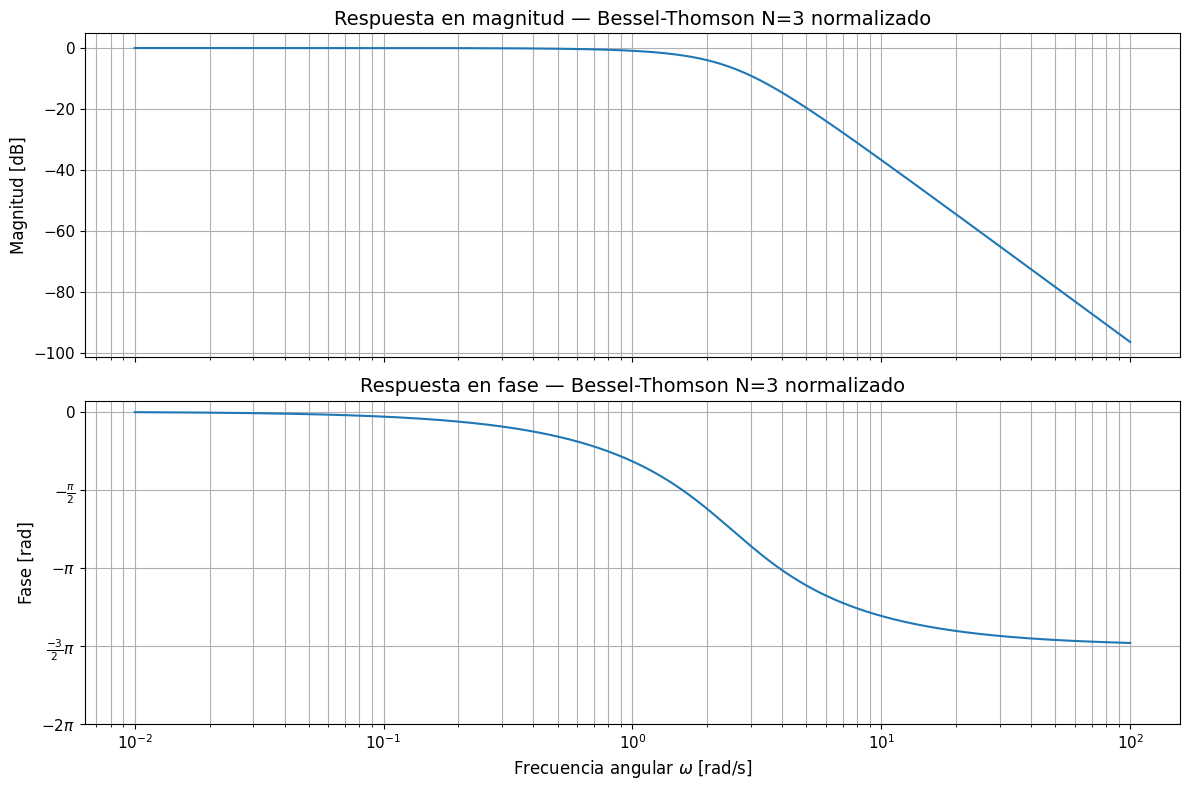

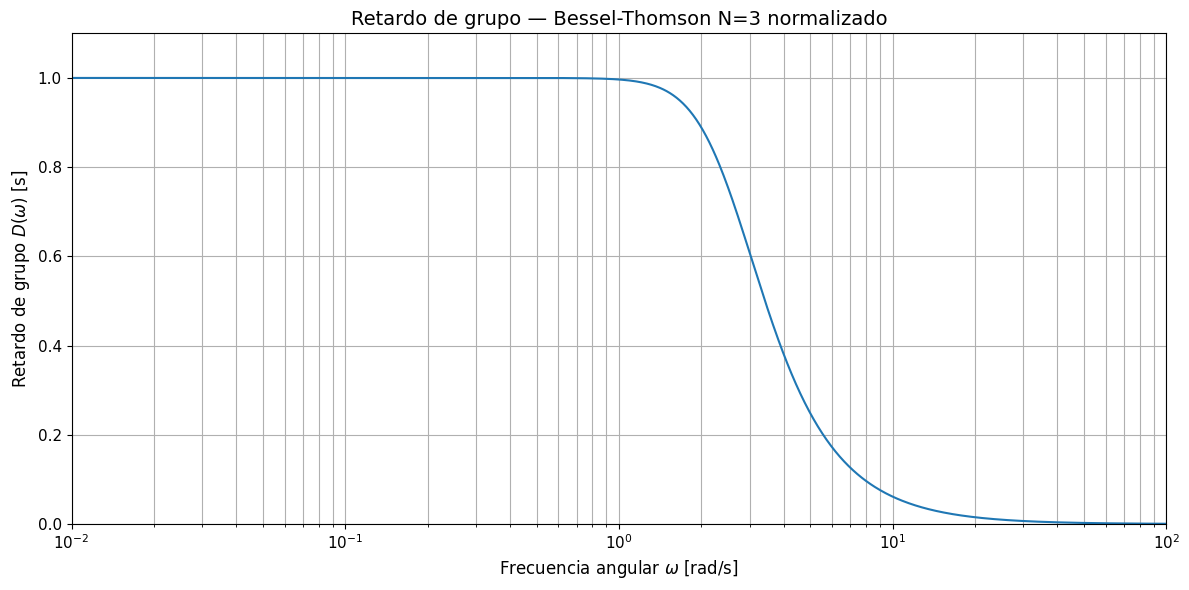

In [24]:
# ============================================================
# Filtro Bessel-Thomson normalizado de orden N = 3
#
#                     15
# T3(s) = ------------------------------
#          s^3 + 6s^2 + 15s + 15
# ============================================================

num = np.array([15.0])
den = np.array([1.0, 6.0, 15.0, 15.0])

T3 = sig.TransferFunction(num, den)

# Puntos característicos
wp = 1.0       # rad/s
ws = 2.5       # rad/s

# Cerrar gráficos anteriores
plt.close('all')

# ============================================================
# 1. Gráfico de módulo y fase con PyTC2
# ============================================================

bodePlot(T3)

fig_bode = plt.gcf()
fig_bode.set_size_inches(12, 8)

ax_mag = fig_bode.axes[0]
ax_fase = fig_bode.axes[1]

ax_mag.set_title('Respuesta en magnitud — Bessel-Thomson N=3 normalizado', fontsize=14)
ax_mag.set_ylabel('Magnitud [dB]', fontsize=12)
ax_mag.grid(True, which='both')
ax_mag.tick_params(labelsize=11)

ax_fase.set_title('Respuesta en fase — Bessel-Thomson N=3 normalizado', fontsize=14)
ax_fase.set_xlabel(r'Frecuencia angular $\omega$ [rad/s]', fontsize=12)
ax_fase.set_ylabel('Fase [rad]', fontsize=12)
ax_fase.grid(True, which='both')
ax_fase.tick_params(labelsize=11)

fig_bode.tight_layout()

# ============================================================
# 2. Retardo de grupo calculado automáticamente con PyTC2
# ============================================================

GroupDelay(T3)

fig_gd = plt.gcf()
fig_gd.set_size_inches(12, 6)

ax_gd = fig_gd.axes[0]

ax_gd.set_title('Retardo de grupo — Bessel-Thomson N=3 normalizado', fontsize=14)
ax_gd.set_xlabel(r'Frecuencia angular $\omega$ [rad/s]', fontsize=12)
ax_gd.set_ylabel(r'Retardo de grupo $D(\omega)$ [s]', fontsize=12)
ax_gd.set_xlim([1e-2, 1e2])
ax_gd.set_ylim([0, 1.1])
ax_gd.grid(True, which='both')
ax_gd.tick_params(labelsize=11)


fig_gd.tight_layout()

plt.show()

---

# Bonus — Desnormalización para $D(\omega=0)=200\mu s$

Como el filtro normalizado fue obtenido para:

$$
D_N(0)=1s
$$

y se pide desnormalizar los componentes para obtener:

$$
D_D(0)=200\mu s
$$

Al aplicar una desnormalización en frecuencia, el retardo de grupo queda escalado según:

$$
D_D(0)=\frac{D_N(0)}{\omega_0}
$$

Como:

$$
D_N(0)=1s
$$

entonces:

$$
200\mu s=\frac{1}{\omega_0}
$$

Por lo tanto:

$$
\omega_0=\frac{1}{200\mu s}
$$

$$
\omega_0=\frac{1}{200\cdot10^{-6}}
$$

$$
\boxed{
\omega_0=5000\ \text{rad/s}
}
$$
## Elección de la norma de impedancia

Se elige una norma de impedancia:

$$
\Omega_Z=100k\Omega
$$

Entonces, las reglas de desnormalización son:

$$
R_D=R_N\cdot\Omega_Z
$$

$$
C_D=\frac{C_N}{\Omega_Z\cdot\omega_0}
$$

Reemplazando:

$$
\Omega_Z=100k\Omega=100000\Omega
$$

$$
\omega_0=5000\ \text{rad/s}
$$

Para los capacitores:

$$
C_D=
\frac{C_N}{100000\cdot5000}
$$

$$
\boxed{
C_D=C_N\cdot2nF}
$$

Por lo tanto:

$$
\boxed{
C_N=1 \Rightarrow C_D=2nF
}
$$

Y para las resistencias:

$$
\boxed{
R_D=R_N\cdot100k\Omega
}
$$

## Valores normalizados para $N=3$

Del circuito normalizado se habían obtenido dos etapas:

### Etapa RC

| Componente | Valor normalizado |
|---|---:|
| $R$ | $0.4306$ |
| $C$ | $1$ |

### Etapa Sallen-Key

| Componente | Valor normalizado |
|---|---:|
| $R_1$ | $0.2847$ |
| $R_2$ | $0.2847$ |
| $C_1$ | $1$ |
| $C_2$ | $1.9102$ |

## Desnormalización de la etapa RC

Para la resistencia:

$$
R_D=R_N\cdot100k\Omega
$$

$$
R_D=0.4306\cdot100k\Omega
$$

$$
R_D=43.06k\Omega
$$

Para el capacitor:

$$
C_D=C_N\cdot2nF
$$

$$
C_D=1\cdot2nF
$$

$$
C_D=2nF
$$

Por lo tanto, para la etapa RC:

$$
\boxed{
R=43.06k\Omega
}
$$

$$
\boxed{
C=2nF
}
$$

## Desnormalización de la etapa Sallen-Key

Para las resistencias:

$$
R_{1D}=R_{1N}\cdot100k\Omega
$$

$$
R_{1D}=0.2847\cdot100k\Omega
$$

$$
R_{1D}=28.47k\Omega
$$

Como:

$$
R_1=R_2
$$

entonces:

$$
R_{2D}=28.47k\Omega
$$

Para el capacitor $C_1$:

$$
C_{1D}=C_{1N}\cdot2nF
$$

$$
C_{1D}=1\cdot2nF
$$

$$
C_{1D}=2nF
$$

Para el capacitor $C_2$:

$$
C_{2D}=C_{2N}\cdot2nF
$$

$$
C_{2D}=1.9102\cdot2nF
$$

$$
C_{2D}=3.8204nF
$$

Por lo tanto:

$$
\boxed{
R_1=R_2=28.47k\Omega
}
$$

$$
\boxed{
C_1=2nF
}
$$

$$
\boxed{
C_2=3.8204nF
}
$$

## <ins>Circuito

<div align="center">
    <img src="./Imagenes/BesselDesNorm.png" alt="Circuito Desnormalizado Bessel" width="1000"/>
</div>

## <ins>Simulación

### Modulo y Fase
<div align="center">
    <img src="./Imagenes/ModuloFaseDesNormalizado.png" alt="Modulo y Fase Bessel Desnormalizado" width="1000"/>
</div>

### Rertardo de grupo
<div align="center">
    <img src="./Imagenes/RetardoDesnorm.png" alt="Retardo de grupo Desnormalizado Bessel" width="1000"/>
</div>

### Valores caracteristicos

<div align="center">
    <img src="./Imagenes/CursoresDesNorm.png" alt="Retardo de grupo Desnormalizado Bessel - Cursores" width="300"/>
</div>


La frecuencia de paso del filtro normalizado era:

$$
\omega_p=1\ \text{rad/s}
$$

Al desnormalizar, esta frecuencia pasa a ser:

$$
\omega_{pD}=\omega_0\cdot\omega_p
$$

$$
\omega_{pD}=5000\ \text{rad/s}
$$

Como LTspice trabaja en Hz:

$$
f_{pD}=\frac{\omega_{pD}}{2\pi}
$$

$$
f_{pD}=\frac{5000}{2\pi}
$$

$$
f_{pD}\approx795.77Hz
$$

En la simulación se ubicó el cursor en:

$$
f=794.64Hz
$$

obteniéndose:

$$
\alpha(\omega_{pD})=0.900dB
$$

$$
D(\omega_{pD})=199.33\mu s
$$

La atenuación obtenida coincide con la condición de diseño:

$$
\boxed{
0.900dB<1dB
\quad \Rightarrow \quad
\text{Cumple}
}
$$

Además, el retardo de grupo se mantiene próximo al valor desnormalizado buscado:

$$
D(0)=200\mu s
$$

Por lo tanto, la simulación verifica correctamente que el filtro fue desnormalizado manteniendo su respuesta de Bessel y escalando el retardo de grupo al valor requerido.

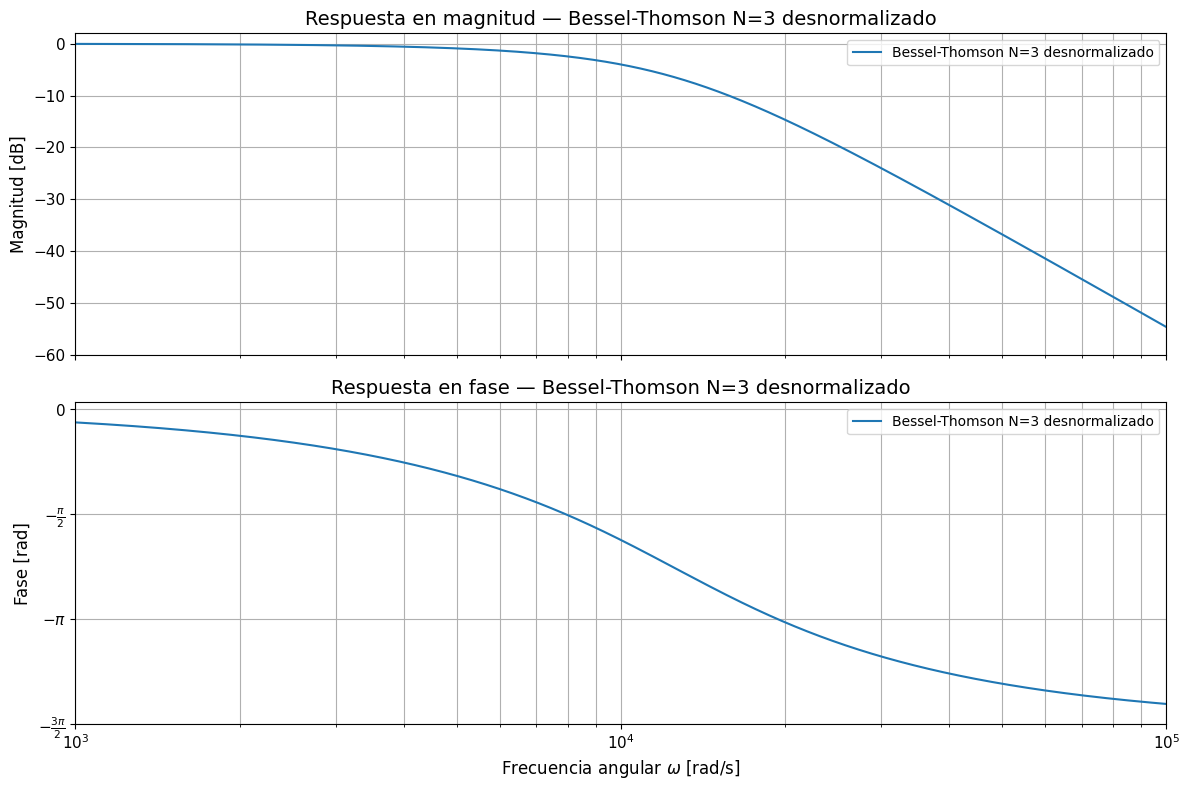

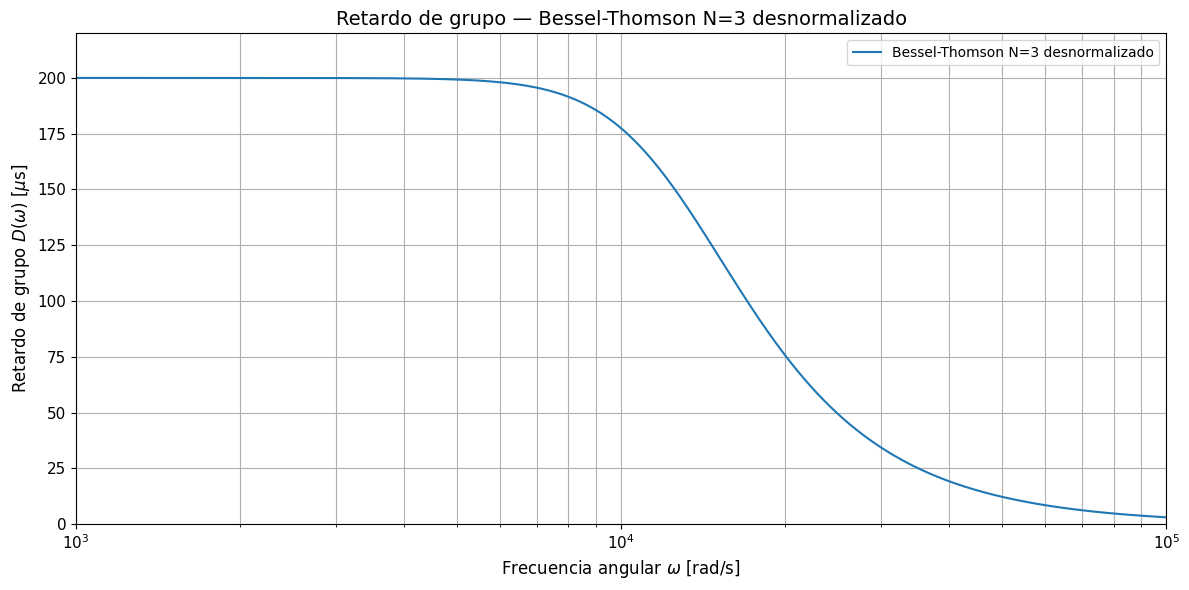

In [7]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

# ============================================================
# Filtro Bessel-Thomson DESNORMALIZADO de orden N = 3
#
#                     15*w0^3
# T3_D(s) = ----------------------------------------------
#            s^3 + 6*w0*s^2 + 15*w0^2*s + 15*w0^3
#
# D(0) = 200 us  -->  w0 = 5000 rad/s
# ============================================================

w0 = 5000.0  # rad/s

num_D = np.array([15.0 * w0**3])

den_D = np.array([
    1.0,
    6.0 * w0,
    15.0 * w0**2,
    15.0 * w0**3
])

T3_D = sig.TransferFunction(num_D, den_D)

n_puntos = 4000

# Límites acordes al rango efectivamente generado por PyTC2
w_min_graf = 1e3
w_max_graf = 1e5

plt.close('all')

# ============================================================
# 1. Magnitud y fase con PyTC2
# ============================================================

fig_id_bode, axes_bode = bodePlot(
    T3_D,
    filter_description='Bessel-Thomson N=3 desnormalizado',
    worN=n_puntos,
    digital=False,
    xaxis='omega',
    unwrap_phase=True
)

fig_bode = plt.figure(fig_id_bode)
fig_bode.set_size_inches(12, 8)

ax_mag = axes_bode[0]
ax_fase = axes_bode[1]

ax_mag.set_title(
    'Respuesta en magnitud — Bessel-Thomson N=3 desnormalizado',
    fontsize=14
)
ax_mag.set_ylabel('Magnitud [dB]', fontsize=12)
ax_mag.set_xlim([w_min_graf, w_max_graf])
ax_mag.set_ylim([-60, 2])
ax_mag.grid(True, which='both')
ax_mag.tick_params(labelsize=11)

ax_fase.set_title(
    'Respuesta en fase — Bessel-Thomson N=3 desnormalizado',
    fontsize=14
)
ax_fase.set_xlabel(r'Frecuencia angular $\omega$ [rad/s]', fontsize=12)
ax_fase.set_ylabel('Fase [rad]', fontsize=12)
ax_fase.set_xlim([w_min_graf, w_max_graf])
ax_fase.set_ylim([-3*np.pi/2, 0.1])

ax_fase.set_yticks([
    0,
    -np.pi/2,
    -np.pi,
    -3*np.pi/2
])

ax_fase.set_yticklabels([
    r'$0$',
    r'$-\frac{\pi}{2}$',
    r'$-\pi$',
    r'$-\frac{3\pi}{2}$'
])

ax_fase.grid(True, which='both')
ax_fase.tick_params(labelsize=11)

fig_bode.tight_layout()

# ============================================================
# 2. Retardo de grupo con PyTC2
# ============================================================

fig_id_gd, ax_gd = GroupDelay(
    T3_D,
    filter_description='Bessel-Thomson N=3 desnormalizado',
    worN=n_puntos,
    digital=False,
    xaxis='omega',
    unwrap_phase=True
)

fig_gd = plt.figure(fig_id_gd)
fig_gd.set_size_inches(12, 6)

ax_gd.set_title(
    'Retardo de grupo — Bessel-Thomson N=3 desnormalizado',
    fontsize=14
)
ax_gd.set_xlabel(r'Frecuencia angular $\omega$ [rad/s]', fontsize=12)
ax_gd.set_ylabel(r'Retardo de grupo $D(\omega)$ [$\mu$s]', fontsize=12)

ax_gd.set_xlim([w_min_graf, w_max_graf])
ax_gd.set_ylim([0, 220e-6])

ax_gd.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, posicion: f'{valor * 1e6:.0f}')
)

ax_gd.grid(True, which='both')
ax_gd.tick_params(labelsize=11)

fig_gd.tight_layout()

plt.show()

---

# <ins> Resolución manuscrita:

## <ins>TS4.pdf: